# HER2-SPAND vs measured predictors — three trastuzumab cohorts

Per-patient HER2-SPAND (Moran's I on the cancer-restricted ErbB-pathway
signature; see [notebook 01](01_spand_pipeline_example.ipynb)) is compared
to measured HER2-related predictors as a marker of treatment response
across three HER2+ trastuzumab cohorts: **PBCP**, **IMPRESS**, and
**TransNEO**.

The three cohorts differ in what "measured HER2" means:

| Cohort | Patients | Measured HER2 predictors |
|---|---|---|
| PBCP    | 18 HER2+      | bulk ERBB2 (log₂ TPM)               |
| IMPRESS | 62 trastuzumab| FISH ratio + IHC (0–3)              |
| TransNEO| 61 trastuzumab| bulk ERBB2 + bulk ErbB-pathway score|

Each cohort runs the same analysis: ROC AUC with bootstrap 95% CIs for
every available predictor, then an exploratory split into HER2-low /
HER2-high halves (by the cohort's natural HER2 axis: bulk ERBB2 for PBCP
and TransNEO, FISH ratio for IMPRESS) to see whether HER2-SPAND adds
signal where the measured marker is less informative. Per-cohort *n* is
small (18 / 62 / 61) — bootstrap CIs are wide and per-stratum CIs are
very wide; the per-stratum split is exploratory, not confirmatory.

This notebook uses **only precomputed per-patient scores** — no inline
pipeline computation. Notebook 01 demonstrates the per-slide pipeline.

**Sign convention.** All three bundled `her2_spand` columns are stored
with the same convention: **higher values predict response = 1**. The
upstream IMPRESS pipeline produced `her2_spand` with the opposite sign;
the IMPRESS parquet was sign-flipped at bundle time so all three cohorts
share the same direction (see the README's reproduction note).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [2]:
def bootstrap_auc(y_true, y_score, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)
    keep = y_score.notna() & y_true.notna()
    y_true, y_score = y_true[keep].reset_index(drop=True), y_score[keep].reset_index(drop=True)
    n = len(y_true)
    if n == 0 or y_true.nunique() < 2:
        return np.nan, np.nan, np.nan, n
    base = roc_auc_score(y_true, y_score)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if y_true.iloc[idx].nunique() < 2:
            continue
        boots.append(roc_auc_score(y_true.iloc[idx], y_score.iloc[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return base, lo, hi, n

def auc_table(df, response_col, predictors, label):
    rows = []
    for name, col in predictors:
        auc, lo, hi, n = bootstrap_auc(df[response_col], df[col])
        rows.append({"stratum": label, "score": name, "auc": auc,
                     "ci_lo": lo, "ci_hi": hi, "n": n})
    return pd.DataFrame(rows)

def plot_auc_bars(result, title, score_order, palette):
    fig, ax = plt.subplots(figsize=(4.8, 3.0))
    strata = result['stratum'].unique().tolist()
    x = np.arange(len(strata)); w = 0.8 / len(score_order)
    for i, s in enumerate(score_order):
        d = result[result.score == s].set_index('stratum').reindex(strata)
        offsets = x + (i - (len(score_order) - 1) / 2) * w
        err = np.vstack([(d['auc'] - d['ci_lo']).clip(lower=0),
                         (d['ci_hi'] - d['auc']).clip(lower=0)])
        ax.bar(offsets, d['auc'], width=w, yerr=err, capsize=3,
               color=palette[s], edgecolor='black', linewidth=0.5, label=s)
    ax.axhline(0.5, color='grey', lw=0.6, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(' (', '\n(') for s in strata], fontsize=7)
    ax.set_ylabel('AUC (95% bootstrap CI)', fontsize=8)
    ax.set_ylim(0, 1.05); ax.tick_params(axis='y', labelsize=7)
    ax.legend(fontsize=6, frameon=False, loc='upper left', ncol=1)
    ax.set_title(title, fontsize=9, loc='left')
    sns.despine(); fig.tight_layout(); plt.show()

## PBCP — 18 HER2+ patients

PBCP per-patient scores: response (1 = pCR, 0 = RD), measured bulk ERBB2
(log₂ TPM), and HER2-SPAND. All 18 patients are `HER2_status == "POS"`
(the HER2+ subset of PBCP per the paper's Application Cohort definition;
the matching HER2− n=19 subset has no `her2_spand` and is not included).

In [3]:
pbcp = pd.read_parquet("../data/pbcp_her2_scores.parquet")
print(f"{len(pbcp)} patients  |  HER2 status: {pbcp['HER2_status'].value_counts().to_dict()}")
print(f"response counts: {pbcp['response'].value_counts().to_dict()}")
pbcp.head()

18 patients  |  HER2 status: {'POS': 18}
response counts: {1: 11, 0: 7}


,slide_name,response,measured_ERBB2_log2_tpm,her2_spand,HER2_status
0,732243,1,11.270,-5.230656,POS
1,732244,1,9.939,-4.534240,POS
2,732250,0,11.512,-6.605669,POS
3,732796,1,8.893,-9.573676,POS
4,732799,1,10.191,-3.577716,POS


In [4]:
# HER2-low/-high split on measured bulk ERBB2
med = pbcp['measured_ERBB2_log2_tpm'].median()
pbcp = pbcp.assign(stratum=np.where(pbcp['measured_ERBB2_log2_tpm'] < med, 'HER2-low (n=9)', 'HER2-high (n=9)'))

preds = [("measured ERBB2 (log2 TPM)", "measured_ERBB2_log2_tpm"),
         ("HER2-SPAND",                 "her2_spand")]
result = pd.concat([
    auc_table(pbcp, 'response', preds, 'all (n=18)'),
    auc_table(pbcp[pbcp.stratum=='HER2-low (n=9)'],  'response', preds, 'HER2-low (n=9)'),
    auc_table(pbcp[pbcp.stratum=='HER2-high (n=9)'], 'response', preds, 'HER2-high (n=9)'),
], ignore_index=True)
result.round(3)

,stratum,score,auc,ci_lo,ci_hi,n
0,all (n=18),measured ERBB2 (log2 TPM),0.714,0.389,0.950,18
1,all (n=18),HER2-SPAND,0.688,0.378,0.929,18
2,HER2-low (n=9),measured ERBB2 (log2 TPM),0.700,0.200,1.000,9
3,HER2-low (n=9),HER2-SPAND,0.600,0.143,1.000,9
4,HER2-high (n=9),measured ERBB2 (log2 TPM),0.429,0.000,1.000,9
5,HER2-high (n=9),HER2-SPAND,0.786,0.333,1.000,9


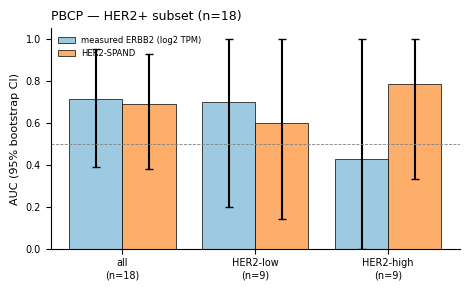

In [5]:
plot_auc_bars(result, 'PBCP — HER2+ subset (n=18)',
              score_order=['measured ERBB2 (log2 TPM)', 'HER2-SPAND'],
              palette={'measured ERBB2 (log2 TPM)': '#9ecae1', 'HER2-SPAND': '#fdae6b'})

## IMPRESS — 62 trastuzumab-treated patients

IMPRESS per-patient scores: response, HER2-SPAND (Moran's I on the cancer-
restricted ErbB pathway, **sign-flipped at bundle time** to match the
PBCP/TransNEO convention), single-gene SPAND on ERBB2, and two measured
HER2 markers — clinical **FISH ratio** (continuous *HER2 / CEP17* copy
number ratio) and **HER2 IHC** (0–3 staining intensity score).

All 62 patients are HER2 IHC ≥ 1 (the trastuzumab arm of IMPRESS); IHC = 3
is the dominant class (n=53). The HER2-low / -high split here uses the
FISH ratio at its median.

In [6]:
imp = pd.read_parquet("../data/impress_her2_scores.parquet")
print(f"{len(imp)} patients  |  IHC: {imp['HER2_IHC'].value_counts(dropna=False).to_dict()}")
print(f"response counts: {imp['response'].value_counts().to_dict()}")
imp.head()

62 patients  |  IHC: {3.0: 53, 2.0: 6, 1.0: 2, 1.5: 1}
response counts: {1: 38, 0: 24}


,slide_name,response,her2_spand,erbb2_single_gene_spand,HER2_FISH_ratio,HER2_IHC
0,000_061_HE.svs,0,-0.517900,-0.309346,4.58,3.0
1,001_062_HE.svs,0,-0.486394,-0.314345,6.03,3.0
2,002_063_HE.svs,0,-0.738047,-0.672566,4.79,3.0
3,003_064_HE.svs,0,-0.814719,-0.789485,3.09,3.0
4,004_065_HE.svs,1,0.027889,0.021458,6.34,3.0


In [7]:
med_fish = imp['HER2_FISH_ratio'].median()
imp = imp.assign(stratum=np.where(imp['HER2_FISH_ratio'] < med_fish,
                                  f'FISH-low (n={int((imp.HER2_FISH_ratio < med_fish).sum())})',
                                  f'FISH-high (n={int((imp.HER2_FISH_ratio >= med_fish).sum())})'))

preds = [("HER2 FISH ratio",    "HER2_FISH_ratio"),
         ("HER2 IHC",           "HER2_IHC"),
         ("HER2-SPAND",         "her2_spand")]
result = pd.concat([
    auc_table(imp, 'response', preds, 'all (n=62)'),
    auc_table(imp[imp.stratum.str.startswith('FISH-low')],  'response', preds, imp.stratum[imp.stratum.str.startswith('FISH-low')].iloc[0]),
    auc_table(imp[imp.stratum.str.startswith('FISH-high')], 'response', preds, imp.stratum[imp.stratum.str.startswith('FISH-high')].iloc[0]),
], ignore_index=True)
result.round(3)

,stratum,score,auc,ci_lo,ci_hi,n
0,all (n=62),HER2 FISH ratio,0.764,0.632,0.888,62
1,all (n=62),HER2 IHC,0.612,0.512,0.714,62
2,all (n=62),HER2-SPAND,0.717,0.564,0.852,62
3,FISH-low (n=31),HER2 FISH ratio,0.618,0.400,0.817,31
4,FISH-low (n=31),HER2 IHC,0.548,0.375,0.711,31
5,FISH-low (n=31),HER2-SPAND,0.601,0.390,0.805,31
6,FISH-high (n=31),HER2 FISH ratio,0.477,0.214,0.735,31
7,FISH-high (n=31),HER2 IHC,0.600,0.500,0.833,31
8,FISH-high (n=31),HER2-SPAND,0.954,0.857,1.000,31


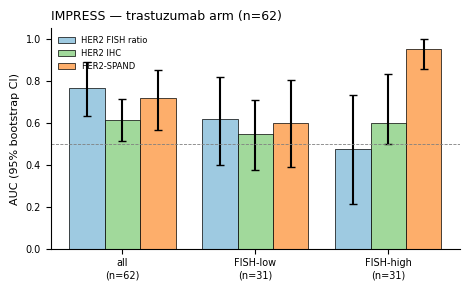

In [8]:
plot_auc_bars(result, 'IMPRESS — trastuzumab arm (n=62)',
              score_order=['HER2 FISH ratio', 'HER2 IHC', 'HER2-SPAND'],
              palette={'HER2 FISH ratio': '#9ecae1', 'HER2 IHC': '#a1d99b', 'HER2-SPAND': '#fdae6b'})

## TransNEO — 61 trastuzumab-treated patients

TransNEO per-patient scores: response, measured bulk ERBB2 (log₂ TPM),
measured bulk ErbB-pathway score, and HER2-SPAND. The HER2-low / -high
split uses bulk ERBB2 at its median.

In [9]:
tn = pd.read_parquet("../data/transneo_her2_scores.parquet")
print(f"{len(tn)} patients  |  response counts: {tn['response'].value_counts().to_dict()}")
tn.head()

61 patients  |  response counts: {0.0: 42, 1.0: 19}


,patient_id,response,measured_ERBB2,measured_pathway,her2_spand
0,T147,0.0,3.343783,0.476798,-0.054178
1,T007,0.0,3.953665,0.459799,0.035096
2,T132,0.0,3.373608,0.507904,-0.027598
3,T115,0.0,3.597076,0.485085,-0.837012
4,T059,1.0,4.127861,0.508416,0.026498


In [10]:
med = tn['measured_ERBB2'].median()
tn = tn.assign(stratum=np.where(tn['measured_ERBB2'] < med,
                                f'HER2-low (n={int((tn.measured_ERBB2 < med).sum())})',
                                f'HER2-high (n={int((tn.measured_ERBB2 >= med).sum())})'))

preds = [("measured ERBB2 (bulk)",        "measured_ERBB2"),
         ("measured ErbB pathway (bulk)", "measured_pathway"),
         ("HER2-SPAND",                   "her2_spand")]
result = pd.concat([
    auc_table(tn, 'response', preds, 'all (n=61)'),
    auc_table(tn[tn.stratum.str.startswith('HER2-low')],  'response', preds, tn.stratum[tn.stratum.str.startswith('HER2-low')].iloc[0]),
    auc_table(tn[tn.stratum.str.startswith('HER2-high')], 'response', preds, tn.stratum[tn.stratum.str.startswith('HER2-high')].iloc[0]),
], ignore_index=True)
result.round(3)

,stratum,score,auc,ci_lo,ci_hi,n
0,all (n=61),measured ERBB2 (bulk),0.660,0.504,0.795,61
1,all (n=61),measured ErbB pathway (bulk),0.639,0.476,0.789,61
2,all (n=61),HER2-SPAND,0.796,0.658,0.902,61
3,HER2-low (n=30),measured ERBB2 (bulk),0.767,0.583,0.920,30
4,HER2-low (n=30),measured ErbB pathway (bulk),0.693,0.456,0.889,30
5,HER2-low (n=30),HER2-SPAND,0.705,0.444,0.912,30
6,HER2-high (n=31),measured ERBB2 (bulk),0.682,0.454,0.890,31
7,HER2-high (n=31),measured ErbB pathway (bulk),0.664,0.455,0.864,31
8,HER2-high (n=31),HER2-SPAND,0.891,0.743,0.991,31


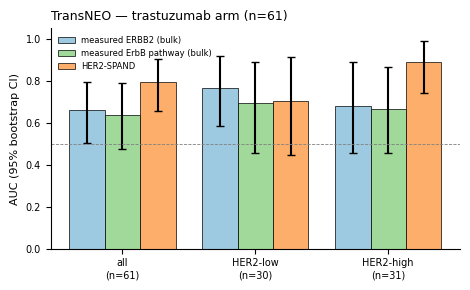

In [11]:
plot_auc_bars(result, 'TransNEO — trastuzumab arm (n=61)',
              score_order=['measured ERBB2 (bulk)', 'measured ErbB pathway (bulk)', 'HER2-SPAND'],
              palette={'measured ERBB2 (bulk)': '#9ecae1', 'measured ErbB pathway (bulk)': '#a1d99b', 'HER2-SPAND': '#fdae6b'})

## Takeaway

Across all three trastuzumab cohorts, HER2-SPAND and the bulk / staining
measured HER2 predictors give broadly comparable pooled AUCs. The two
kinds of scores are not interchangeable: HER2-SPAND captures the
**spatial pattern** of the cancer-restricted ErbB-pathway signature, while
the measured predictors (bulk ERBB2 TPM, FISH ratio, IHC score) summarize
HER2 abundance averaged over the whole specimen.

Per-stratum splits in all three cohorts have small *n* (9 / 31 / 30 per
side) and bootstrap CIs that span most of the [0, 1] interval, so the
per-stratum bars should be read as exploratory: they suggest where the two
kinds of scores trade off, but a much larger cohort would be needed to
characterize where each one wins. The pooled-AUC bars are the more
reliable summary at these sample sizes.